# DataFrame에서 날짜/시간(datetime) 타입 데이터 다루기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SPX 주가 데이터셋

In [2]:
file_path='https://github.com/wesm/pydata-book/raw/refs/heads/3rd-edition/examples/spx.csv'

In [3]:
spx=pd.read_csv(file_path)

In [4]:
spx

,Date,SPX
0,1990-02-01 00:00:00,328.79
1,1990-02-02 00:00:00,330.92
2,1990-02-05 00:00:00,331.85
3,1990-02-06 00:00:00,329.66
4,1990-02-07 00:00:00,333.75
...,...,...
5467,2011-10-10 00:00:00,1194.89
5468,2011-10-11 00:00:00,1195.54
5469,2011-10-12 00:00:00,1207.25
5470,2011-10-13 00:00:00,1203.66


In [5]:
spx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5472 entries, 0 to 5471
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5472 non-null   object 
 1   SPX     5472 non-null   float64
dtypes: float64(1), object(1)
memory usage: 85.6+ KB


# 문자열 타입의 컬럼을 datetime 타입으로 변환

In [6]:
spx.Date=pd.to_datetime(spx.Date) # spx에 Date컬럼을 datetime형식으로

In [7]:
spx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5472 entries, 0 to 5471
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5472 non-null   datetime64[ns]
 1   SPX     5472 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 85.6 KB


# csv 파일에서 DataFrame을 생성할 때 날짜/시간 컬럼과 형식을 지정

In [8]:
spx=pd.read_csv(file_path,
                parse_dates=['Date'],
                date_format={'Date':'%Y-%m-%d %H:%M:%S'})

In [9]:
spx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5472 entries, 0 to 5471
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5472 non-null   datetime64[ns]
 1   SPX     5472 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 85.6 KB


# 기간별(연도별, 분기별, 월별, ...) 통계

* sep >>> datetime

In [10]:
# Date 컬럼(datetime 타입)을 인덱스로 변환. set_index 인덱스로 reset_index 컬럼으로
spx_index= spx.set_index('Date')

In [11]:
spx_index.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5472 entries, 1990-02-01 to 2011-10-14
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPX     5472 non-null   float64
dtypes: float64(1)
memory usage: 85.5 KB


In [12]:
# 연도별 주가 평균 pandas에서 rule보고오기 resample은 groupby와비슷
spx_by_year=spx_index.resample(rule='YE').mean() #YE는 YEAR의 앞 두글자 ㄴㄴ Y =year e=말일, s=초일
# 1 시간을 인덱스로 2 리셈플


In [13]:
spx_by_year.head()

,SPX
Date,
1990-12-31,334.123506
1991-12-31,376.186324
1992-12-31,415.747008
1993-12-31,451.614822
1994-12-31,460.416508


In [14]:
spx_by_year.tail()

,SPX
Date,
2007-12-31,1477.184343
2008-12-31,1220.042055
2009-12-31,948.046389
2010-12-31,1139.965516
2011-12-31,1276.093015


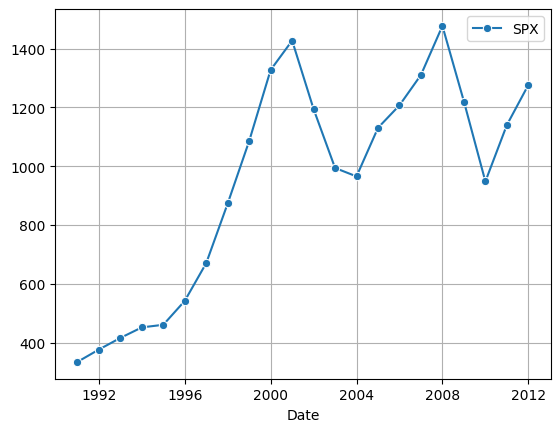

In [15]:
sns.lineplot(data=spx_by_year,marker='o')
plt.grid()
# plt.ylabel('SPX')
plt.show()

In [16]:
# 분기별 주가평균
spx_by_quarter=spx_index.resample(rule='QE').mean()
spx_by_quarter.head(n=6)

,SPX
Date,
1990-03-31,334.751951
1990-06-30,349.796508
1990-09-30,335.881746
1990-12-31,316.562031
1991-03-31,352.282951
1991-06-30,378.665937


In [17]:
spx_by_quarter.tail(n=6)

,SPX
Date,
2010-09-30,1096.246875
2010-12-31,1204.585625
2011-03-31,1302.529032
2011-06-30,1318.332857
2011-09-30,1225.268438
2011-12-31,1171.356000


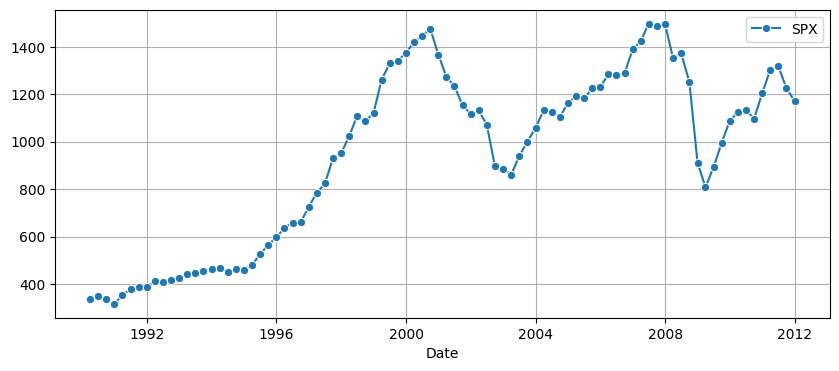

In [18]:
plt.figure(figsize=(10,4))
sns.lineplot(data=spx_by_quarter,marker='o')
plt.grid()
plt.show()

In [19]:
# month
spx_by_month=spx_index.resample(rule='ME').mean()
spx_by_month

,SPX
Date,
1990-02-28,330.452632
1990-03-31,338.465000
1990-04-30,338.178000
1990-05-31,350.250000
1990-06-30,360.386667
...,...
2011-06-30,1287.288636
2011-07-31,1325.184500
2011-08-31,1185.305652


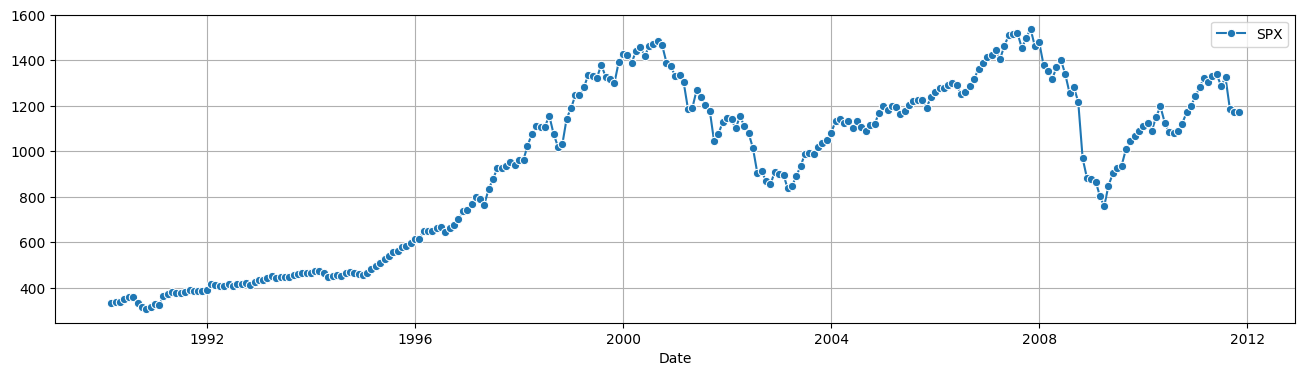

In [20]:
plt.figure(figsize=(16,4))
sns.lineplot(data=spx_by_month,marker='o')
plt.grid()
plt.show()

# plt.figure(figsize=(16, 4))
# sns.lineplot(data=spx_by_month)
# plt.grid()
# plt.show()

# banklist 데이터셋

* [banklist.csv](https://github.com/JakeOh/202511_BD53/blob/main/datasets/banklist.csv)  파일을 읽고 데이터프레임을 생성.
* 데이터프레임을 생성할 때 날짜/시간(datetime) 타입으로 변환할 수 있는 모든 컬럼들은 날짜/시간 타입으로 변환.
* 연도별 파산한 은행 숫자 시각화.
* 분기별 파산한 은행 숫자 시각화.
* 월별 파산한 은행 숫자 시각화.
* 기간별 통계는 Closing Date를 기준으로.

In [41]:
file_path='https://github.com/JakeOh/202511_BD53/raw/refs/heads/main/datasets/banklist.csv'

In [22]:
bank=pd.read_csv(file_path,)
                #  parse_dates=['Closing Date','Updated Date'],
                #  index_col=('Closing Date'))
                #  date_format={'%d-%mm-%y','%d-%mm-%y'})

In [36]:
bank

,Bank Name,City,ST,CERT,Acquiring Institution,Updated Date
Closing Date,,,,,,
2017-12-15,Washington Federal Bank for Savings,Chicago,IL,30570,Royal Savings Bank,20-Dec-17
2017-10-13,The Farmers and Merchants State Bank of Argonia,Argonia,KS,17719,Conway Bank,20-Oct-17
2017-05-26,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",26-Jul-17
2017-05-05,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,26-Jul-17
2017-04-28,First NBC Bank,New Orleans,LA,58302,Whitney Bank,5-Dec-17
...,...,...,...,...,...,...
2001-07-27,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",19-Aug-14
2001-05-03,Malta National Bank,Malta,OH,6629,North Valley Bank,18-Nov-02
2001-02-02,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,18-Feb-03


In [38]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 555 entries, 2017-12-15 to 2000-10-13
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Bank Name              555 non-null    object
 1   City                   555 non-null    object
 2   ST                     555 non-null    object
 3   CERT                   555 non-null    int64 
 4   Acquiring Institution  555 non-null    object
 5   Updated Date           555 non-null    object
dtypes: int64(1), object(5)
memory usage: 30.4+ KB


In [25]:
bank['Closing Date'] = pd.to_datetime(bank['Closing Date'])
bank = bank.set_index('Closing Date')

# bank['Updated Date'] = pd.to_datetime(bank['Updated Date'])
# bank = bank.set_index('Updated Date')


/tmp/ipython-input-857545291.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bank['Closing Date'] = pd.to_datetime(bank['Closing Date'])


In [40]:
bank

,Bank Name,City,ST,CERT,Acquiring Institution,Updated Date
Closing Date,,,,,,
2017-12-15,Washington Federal Bank for Savings,Chicago,IL,30570,Royal Savings Bank,2017-12-20
2017-10-13,The Farmers and Merchants State Bank of Argonia,Argonia,KS,17719,Conway Bank,2017-10-20
2017-05-26,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",2017-07-26
2017-05-05,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,2017-07-26
2017-04-28,First NBC Bank,New Orleans,LA,58302,Whitney Bank,2017-12-05
...,...,...,...,...,...,...
2001-07-27,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",2014-08-19
2001-05-03,Malta National Bank,Malta,OH,6629,North Valley Bank,2002-11-18
2001-02-02,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2003-02-18


In [26]:
bank.index=pd.to_datetime(bank.index)

In [68]:
bank_by_year=bank.resample(rule='YE').count()#sum(numeric_only=True)
bank_by_year


,Bank Name,City,ST,CERT,Acquiring Institution,Updated Date
Closing Date,,,,,,
2000-12-31,2,2,2,2,2,2
2001-12-31,4,4,4,4,4,4
2002-12-31,11,11,11,11,11,11
2003-12-31,3,3,3,3,3,3
2004-12-31,4,4,4,4,4,4
2005-12-31,0,0,0,0,0,0
2006-12-31,0,0,0,0,0,0
2007-12-31,3,3,3,3,3,3
2008-12-31,25,25,25,25,25,25


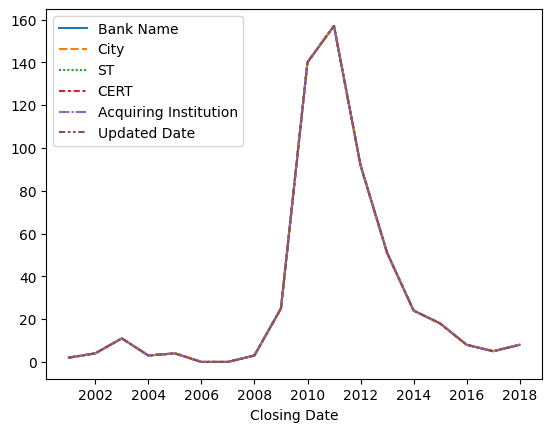

In [69]:
sns.lineplot(data=bank_by_year)
plt.show()

In [64]:
bank_by_quarter=bank.resample('QE').count()#numeric_only=True


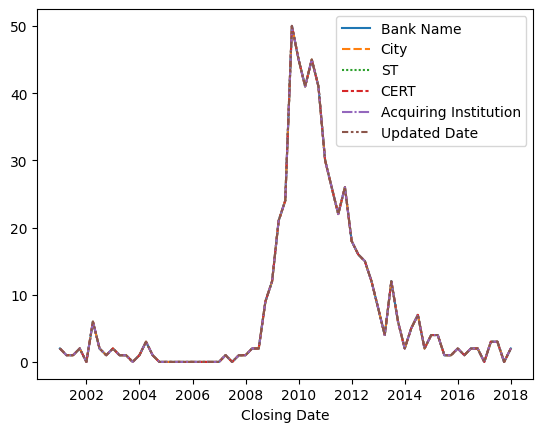

In [65]:
sns.lineplot(data=bank_by_quarter)
plt.show()

In [70]:
bank_by_month=bank.resample('ME').count()#sum(numeric_only=True)

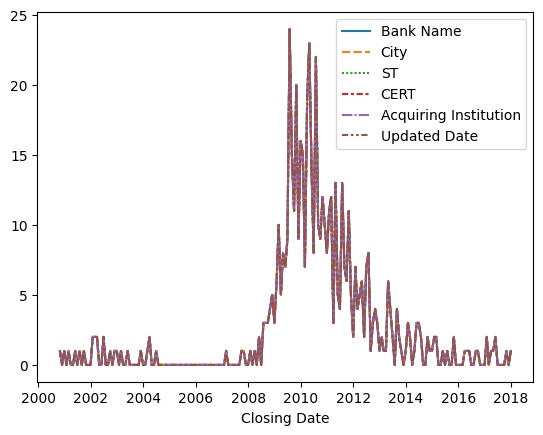

In [71]:
sns.lineplot(data=bank_by_month)
plt.show()

In [33]:
# spx_index= spx.set_index('Date')
# bank_cloindex=bank.set_index('Closing Date')
# bank_Updindex=bank.set_index('Updated Date')

KeyError: "None of ['Closing Date'] are in the columns"

In [39]:
# bank['Closing Date']=pd.to_datetime(bank['Closing Date'])
bank['Updated Date']=pd.to_datetime(bank['Updated Date'])

/tmp/ipython-input-462026159.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bank['Updated Date']=pd.to_datetime(bank['Updated Date'])


In [35]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 555 entries, 2017-12-15 to 2000-10-13
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Bank Name              555 non-null    object
 1   City                   555 non-null    object
 2   ST                     555 non-null    object
 3   CERT                   555 non-null    int64 
 4   Acquiring Institution  555 non-null    object
 5   Updated Date           555 non-null    object
dtypes: int64(1), object(5)
memory usage: 30.4+ KB


In [ ]:
# bank_index= bank.set_index('Closing Date')

In [ ]:
bank

In [ ]:
# bank['Closing Date'] = pd.to_datetime(bank['Closing Date'])
# bank = bank.set_index('Closing Date')


In [ ]:
bank.dtypes

In [ ]:
# bank.index=pd.to_datetime(bank.index)

In [42]:
banklist=pd.read_csv(file_path)

In [43]:
banklist

,Bank Name,City,ST,CERT,Acquiring Institution,Closing Date,Updated Date
0,Washington Federal Bank for Savings,Chicago,IL,30570,Royal Savings Bank,15-Dec-17,20-Dec-17
1,The Farmers and Merchants State Bank of Argonia,Argonia,KS,17719,Conway Bank,13-Oct-17,20-Oct-17
2,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",26-May-17,26-Jul-17
3,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,5-May-17,26-Jul-17
4,First NBC Bank,New Orleans,LA,58302,Whitney Bank,28-Apr-17,5-Dec-17
...,...,...,...,...,...,...,...
550,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",27-Jul-01,19-Aug-14
551,Malta National Bank,Malta,OH,6629,North Valley Bank,3-May-01,18-Nov-02
552,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2-Feb-01,18-Feb-03
553,National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,14-Dec-00,17-Mar-05


In [45]:
banklist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Bank Name              555 non-null    object
 1   City                   555 non-null    object
 2   ST                     555 non-null    object
 3   CERT                   555 non-null    int64 
 4   Acquiring Institution  555 non-null    object
 5   Closing Date           555 non-null    object
 6   Updated Date           555 non-null    object
dtypes: int64(1), object(6)
memory usage: 30.5+ KB


In [50]:
banklist['Closing Date']=pd.to_datetime(banklist['Closing Date'],format='%d-%b-%y')#dayfirst=True B=march b=mar

In [52]:
banklist['Updated Date']=pd.to_datetime(banklist['Updated Date'],format='%d-%b-%y')#dayfirst=True B=march b=mar

In [53]:
bank

,Bank Name,City,ST,CERT,Acquiring Institution,Updated Date
Closing Date,,,,,,
2017-12-15,Washington Federal Bank for Savings,Chicago,IL,30570,Royal Savings Bank,2017-12-20
2017-10-13,The Farmers and Merchants State Bank of Argonia,Argonia,KS,17719,Conway Bank,2017-10-20
2017-05-26,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",2017-07-26
2017-05-05,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,2017-07-26
2017-04-28,First NBC Bank,New Orleans,LA,58302,Whitney Bank,2017-12-05
...,...,...,...,...,...,...
2001-07-27,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",2014-08-19
2001-05-03,Malta National Bank,Malta,OH,6629,North Valley Bank,2002-11-18
2001-02-02,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2003-02-18


In [54]:
banklist_indexed=banklist.set_index('Closing Date')

## 기간별 통계(resampling)

In [57]:
def lineplot_resample(rule):
  df = banklist_indexed.resample(rule).size()# 갯수호출
  plt.figure(figsize=(20,4))
  sns.lineplot(data=df,marker='o')
  plt.grid()
  plt.show()

In [56]:
banklist_indexed.resample('YE').size() # 갯수호출

,0
Closing Date,
2000-12-31,2
2001-12-31,4
2002-12-31,11
2003-12-31,3
2004-12-31,4
2005-12-31,0
2006-12-31,0
2007-12-31,3
2008-12-31,25


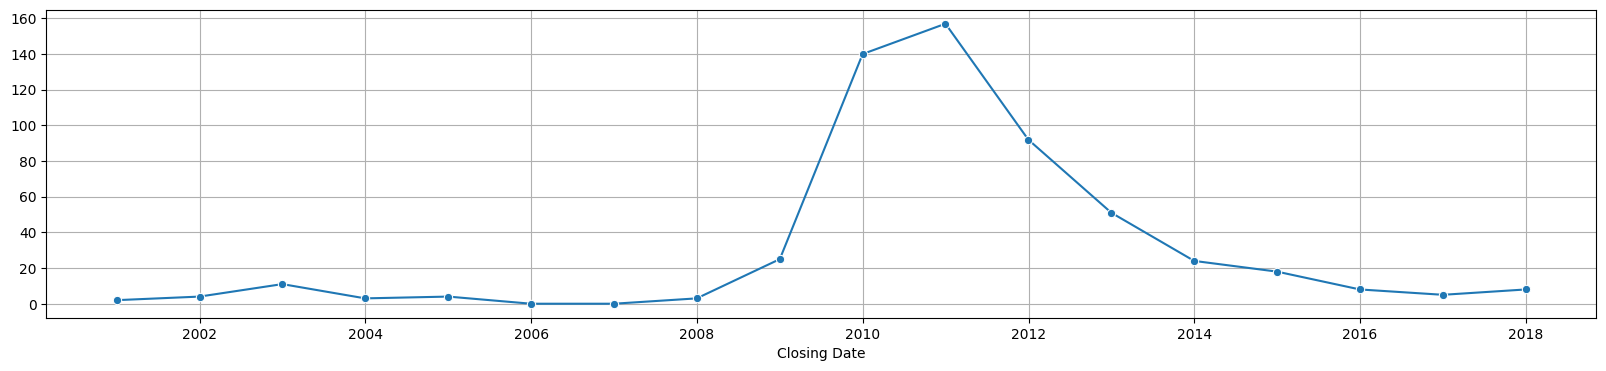

In [58]:
lineplot_resample(rule='YE')

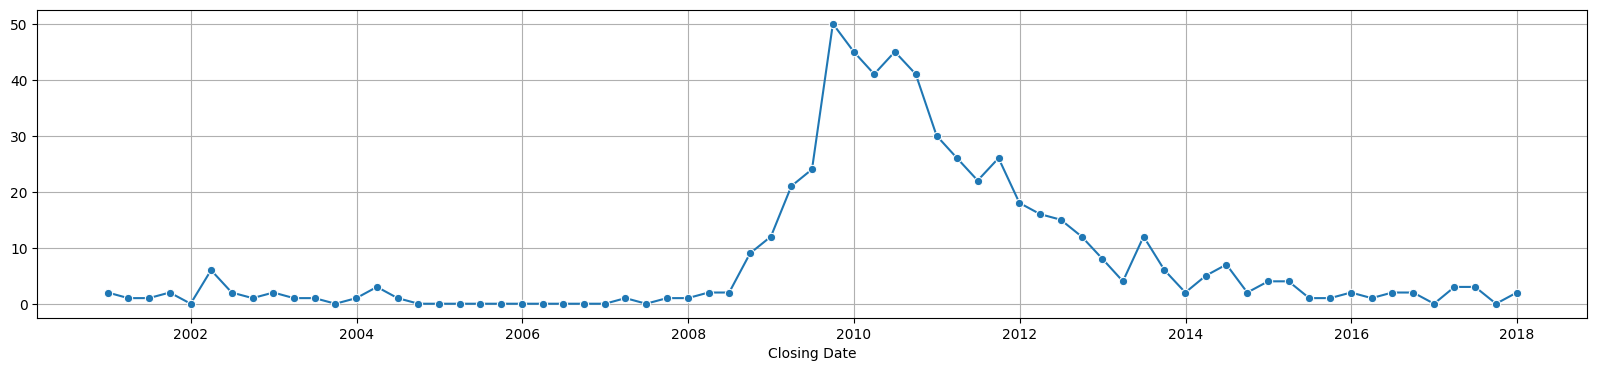

In [59]:
lineplot_resample(rule='QE')

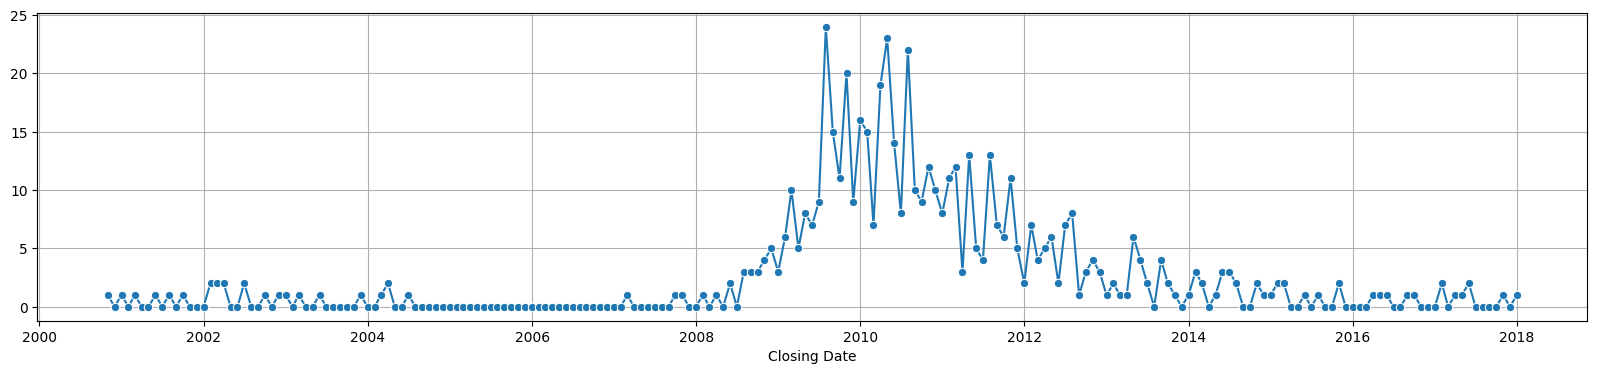

In [62]:
lineplot_resample(rule='ME')